# 09 Hugging Face ViT Transfer Learning

1.   Στοιχείο λίστας
2.   Στοιχείο λίστας



## 1. Setup

This notebook fine-tunes a pretrained Hugging Face image-classification
transformer on CIFAR-100 fine labels. It is fully standalone: no local
package imports, no file-writing magics, no shell git operations.

Run A is a frozen-backbone head baseline. Run B is a partial fine-tune.
Run C (optional) is LoRA via `peft`. LoRA is skipped gracefully if `peft`
fails to install or to wrap the chosen backbone.

[![Open 09 in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fgram-devAI/deepl-cifar100-image-analysis/blob/main/notebooks/09_hf_vit_transfer_learning.ipynb)

In [1]:
%pip install -q --upgrade pip
%pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.8 MB/s eta 0:00:00


In [2]:
RUN_LORA = True  # set to True to attempt LoRA Run C
PEFT_AVAILABLE = False

If you set `RUN_LORA = True`, run this dependency cell first:

In [3]:
# Guarded equivalent of `%pip install -q peft`.
# Using run_line_magic keeps the cell valid Python when RUN_LORA is False.
if RUN_LORA:
    get_ipython().run_line_magic("pip", "install -q peft")

In [4]:
if RUN_LORA:
    try:
        import peft  # noqa: F401
        PEFT_AVAILABLE = True
    except Exception as exc:
        print(f"PEFT import failed; LoRA Run C will be skipped: {exc}")
        PEFT_AVAILABLE = False

In [5]:
# Upgrade torchao to meet PEFT's compatibility requirements.
# The error indicates version 0.10.0 is found, but >0.16.0 is needed.
%pip install -q --upgrade torchao>=0.16.0

In [6]:
import json
import os
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

FAST_DEV_RUN = False       # small subsets, 1 epoch — used for smoke tests
RUN_TRAINING = True       # set False to only inspect data/model
MODEL_NAME = "google/vit-base-patch16-224" # Changed from "google/vit-base-patch16-224-in21k"

OUTPUT_ROOT = Path("/content/hf_vit_transfer") if Path("/content").exists() else Path("results/hf_vit_transfer")
RUN_A_DIR = OUTPUT_ROOT / "run_a_frozen_head"
RUN_B_DIR = OUTPUT_ROOT / "run_b_partial_finetune"
RUN_C_DIR = OUTPUT_ROOT / "run_c_lora"

def ensure_dirs():
    for d in (RUN_A_DIR, RUN_B_DIR, RUN_C_DIR):
        d.mkdir(parents=True, exist_ok=True)

ensure_dirs()
print(f"output root: {OUTPUT_ROOT}")

device: cuda
output root: /content/hf_vit_transfer


## 2. Load CIFAR-100 (fine labels, 100 classes)

We load `uoft-cs/cifar100` from Hugging Face Datasets. Validation is a
stratified 0.1 split off the train set. When `FAST_DEV_RUN` is True we
subset to 2,000 train, 500 val, and 500 test rows for quick smoke runs.

In [7]:
import datasets

raw = datasets.load_dataset("uoft-cs/cifar100")
print(raw)

# Verify fine-label column and capture names.
label_col = "fine_label"
assert label_col in raw["train"].column_names, raw["train"].column_names
NUM_LABELS = raw["train"].features[label_col].num_classes
LABEL_NAMES = raw["train"].features[label_col].names
assert NUM_LABELS == 100, NUM_LABELS

# Stratified split for validation.
split = raw["train"].train_test_split(
    test_size=0.1, stratify_by_column=label_col, seed=SEED
)
raw_train = split["train"]
raw_val = split["test"]
raw_test = raw["test"]

if FAST_DEV_RUN:
    raw_train = raw_train.shuffle(seed=SEED).select(range(2_000))
    raw_val = raw_val.shuffle(seed=SEED).select(range(500))
    raw_test = raw_test.shuffle(seed=SEED).select(range(500))

print(f"train: {len(raw_train)} | val: {len(raw_val)} | test: {len(raw_test)}")
print(f"num_labels: {NUM_LABELS}; sample names: {LABEL_NAMES[:5]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.98k [00:00<?, ?B/s]

cifar100/train-00000-of-00001.parquet:   0%|          | 0.00/119M [00:00<?, ?B/s]

cifar100/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 10000
    })
})
train: 45000 | val: 5000 | test: 10000
num_labels: 100; sample names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']...


## 3. Why ViT Uses Unmasked Self-Attention for Image Classification

A ViT splits each image into fixed-size patches (e.g. 16×16). Each patch
is linearly embedded into a token, a positional embedding is added, and
the token sequence is fed through a stack of transformer encoder blocks.

For **image classification** the whole image is available at once, so
every patch token is allowed to attend to every other patch token. This
is *bidirectional / unmasked self-attention*. There is no causal order to
enforce, so masking would only throw away useful global context.

*Masked* (causal) self-attention is mainly used in **autoregressive
sequence prediction** — e.g. next-token language models — where the
model must not see future tokens during training. That setup is out of
scope for this image-classification branch and is not implemented here.

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model: google/vit-base-patch16-224
  hidden_size:        768
  num_hidden_layers:  12
  num_attention_heads:12
  patch_size:         16
  image_size:         224


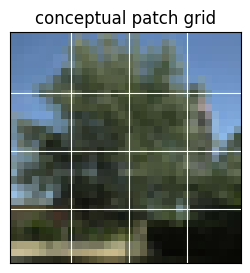

In [8]:
import math
import matplotlib.pyplot as plt
from transformers import AutoConfig

# Inspect the chosen pretrained model's transformer configuration.
cfg = AutoConfig.from_pretrained(MODEL_NAME)
print(f"model: {MODEL_NAME}")
print(f"  hidden_size:        {cfg.hidden_size}")
print(f"  num_hidden_layers:  {cfg.num_hidden_layers}")
print(f"  num_attention_heads:{cfg.num_attention_heads}")
print(f"  patch_size:         {getattr(cfg, 'patch_size', 'n/a')}")
print(f"  image_size:         {getattr(cfg, 'image_size', 'n/a')}")

# Show one CIFAR-100 image split into a conceptual 4x4 patch grid.
sample = raw_train[0]["img"]
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample)
grid = 4
w, h = sample.size
for i in range(1, grid):
    ax.axvline(i * w / grid, color="white", linewidth=0.8)
    ax.axhline(i * h / grid, color="white", linewidth=0.8)
ax.set_title("conceptual patch grid")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 4. Preprocessing — Image Processor and Transforms

We use the model's bundled `AutoImageProcessor` to resize, normalize, and
tensor-convert each PIL image. Training adds a light random horizontal
flip; validation/test use only the processor's deterministic transform.
Labels are surfaced under the key `labels` to satisfy the HF `Trainer`.

In [9]:
from transformers import AutoImageProcessor
from torchvision.transforms import (
    Compose, Normalize, RandomHorizontalFlip, Resize, ToTensor,
)

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
image_mean = processor.image_mean
image_std = processor.image_std
image_size = processor.size.get("height", 224)

train_tf = Compose([
    Resize((image_size, image_size)),
    RandomHorizontalFlip(p=0.5),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std),
])
eval_tf = Compose([
    Resize((image_size, image_size)),
    ToTensor(),
    Normalize(mean=image_mean, std=image_std),
])

def _apply(batch, tf):
    batch["pixel_values"] = [tf(img.convert("RGB")) for img in batch["img"]]
    batch["labels"] = batch["fine_label"]
    return batch

train_ds = raw_train.with_transform(lambda b: _apply(b, train_tf))
val_ds = raw_val.with_transform(lambda b: _apply(b, eval_tf))
test_ds = raw_test.with_transform(lambda b: _apply(b, eval_tf))

def collate_fn(batch):
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "labels": torch.tensor([b["labels"] for b in batch], dtype=torch.long),
    }

# Sanity check one batch shape.
sample_batch = collate_fn([train_ds[i] for i in range(4)])
print({k: tuple(v.shape) for k, v in sample_batch.items()})

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

{'pixel_values': (4, 3, 224, 224), 'labels': (4,)}


## 5. Training Utilities

Shared helpers for the three runs: metric computation, a `TrainingArguments`
builder, a `Trainer` builder, and an artifact saver that writes metrics,
the trainer log history, a confusion matrix, a worst-20 per-class F1 plot,
and a misclassified-examples grid for each run.

In [15]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, top_k_accuracy_score,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    labels_arr = np.asarray(labels)
    return {
        "accuracy": float(accuracy_score(labels_arr, preds)),
        "macro_f1": float(f1_score(labels_arr, preds, average="macro", zero_division=0)),
        "top3": float(top_k_accuracy_score(labels_arr, logits, k=3, labels=list(range(NUM_LABELS)))),
        "top5": float(top_k_accuracy_score(labels_arr, logits, k=5, labels=list(range(NUM_LABELS)))),
    }

def build_training_args(out_dir, *, epochs, lr, batch_size, weight_decay=0.01):
    common = dict(
        output_dir=str(out_dir / "trainer"),
        num_train_epochs=1 if FAST_DEV_RUN else epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=weight_decay,
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False,
        dataloader_num_workers=2,
    )
    try:
        return TrainingArguments(evaluation_strategy="epoch", **common)
    except TypeError:
        # Newer Transformers versions renamed evaluation_strategy to eval_strategy.
        return TrainingArguments(eval_strategy="epoch", **common)

def build_trainer(model, args):
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
    )

In [16]:
def save_run_artifacts(trainer, out_dir, pred_dataset, image_dataset, label_names):
    out_dir.mkdir(parents=True, exist_ok=True)

    pred_out = trainer.predict(pred_dataset)
    logits = pred_out.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    labels = np.asarray(pred_out.label_ids)
    preds = np.argmax(logits, axis=-1)

    metrics = compute_metrics((logits, labels))
    (out_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))
    history = trainer.state.log_history
    (out_dir / "history.json").write_text(json.dumps(history, indent=2))

    # Training curves: loss and (when present) eval accuracy/f1 per epoch.
    train_loss = [(e["epoch"], e["loss"]) for e in history if "loss" in e and "eval_loss" not in e]
    eval_loss = [(e["epoch"], e["eval_loss"]) for e in history if "eval_loss" in e]
    eval_acc = [(e["epoch"], e["eval_accuracy"]) for e in history if "eval_accuracy" in e]
    if train_loss or eval_loss:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        if train_loss:
            xs, ys = zip(*train_loss)
            axes[0].plot(xs, ys, label="train loss")
        if eval_loss:
            xs, ys = zip(*eval_loss)
            axes[0].plot(xs, ys, label="eval loss")
        axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
        axes[0].set_title("loss")
        if eval_acc:
            xs, ys = zip(*eval_acc)
            axes[1].plot(xs, ys, label="eval accuracy")
        axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
        axes[1].set_title("accuracy")
        fig.tight_layout()
        fig.savefig(out_dir / "training_curves.png", dpi=120)
        plt.show()

    # Confusion matrix (linear scale; 100 classes so we skip ticks).
    cm = confusion_matrix(labels, preds, labels=list(range(len(label_names))))
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(cm, aspect="auto")
    ax.set_title("confusion matrix (test)")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    fig.tight_layout()
    fig.savefig(out_dir / "confusion_matrix.png", dpi=120)
    plt.show()

    # Worst-20 per-class F1.
    per_class_f1 = f1_score(labels, preds, average=None, zero_division=0,
                            labels=list(range(len(label_names))))
    order = np.argsort(per_class_f1)[:20]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([label_names[i] for i in order][::-1],
            [per_class_f1[i] for i in order][::-1])
    ax.set_xlabel("F1"); ax.set_title("worst-20 per-class F1 (test)")
    fig.tight_layout()
    fig.savefig(out_dir / "per_class_f1_worst20.png", dpi=120)
    plt.show()

    # Misclassified-examples grid (up to 16).
    wrong_idx = np.where(preds != labels)[0][:16]
    if len(wrong_idx) > 0:
        cols = 4
        rows = math.ceil(len(wrong_idx) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
        axes = np.atleast_2d(axes)
        for ax in axes.flat:
            ax.axis("off")
        for ax, idx in zip(axes.flat, wrong_idx):
            ax.imshow(image_dataset[int(idx)]["img"])
            ax.set_title(
                f"y={label_names[int(labels[idx])]}\np={label_names[int(preds[idx])]}",
                fontsize=7,
            )
        fig.tight_layout()
        fig.savefig(out_dir / "misclassified_examples.png", dpi=120)
        plt.show()

    print(json.dumps(metrics, indent=2))
    return metrics

> `trainer.predict` is called against `test_ds` (transformed), and the
> misclassified grid renders from `raw_test` (PIL images). Always pass
> both as `save_run_artifacts(..., test_ds, raw_test, LABEL_NAMES)`.

## 6. Run A — Frozen Backbone, Head-Only Training

Backbone parameters are frozen; only the classifier head trains.
Recommended settings: 5–10 epochs, batch size 32 if memory allows,
learning rate around 3e-4 to 1e-3, weight decay 0.01.
`FAST_DEV_RUN` forces 1 epoch and the subsetted data for a fast smoke run.

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Run A trainable params: 76,900 / 85,875,556 (0.09%) Kishan)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Top3,Top5
1,0.986755,0.572985,0.841000,0.840036,0.948400,0.970200
2,0.498374,0.520317,0.851200,0.851542,0.954200,0.975000
3,0.426300,0.498497,0.857000,0.856607,0.957400,0.977200
4,0.385616,0.489964,0.855800,0.855392,0.958400,0.978200
5,0.362973,0.487392,0.858200,0.857651,0.959000,0.977400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

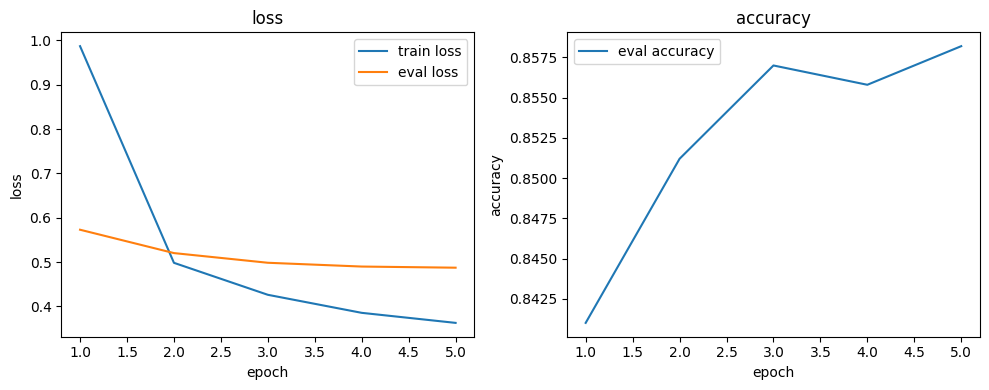

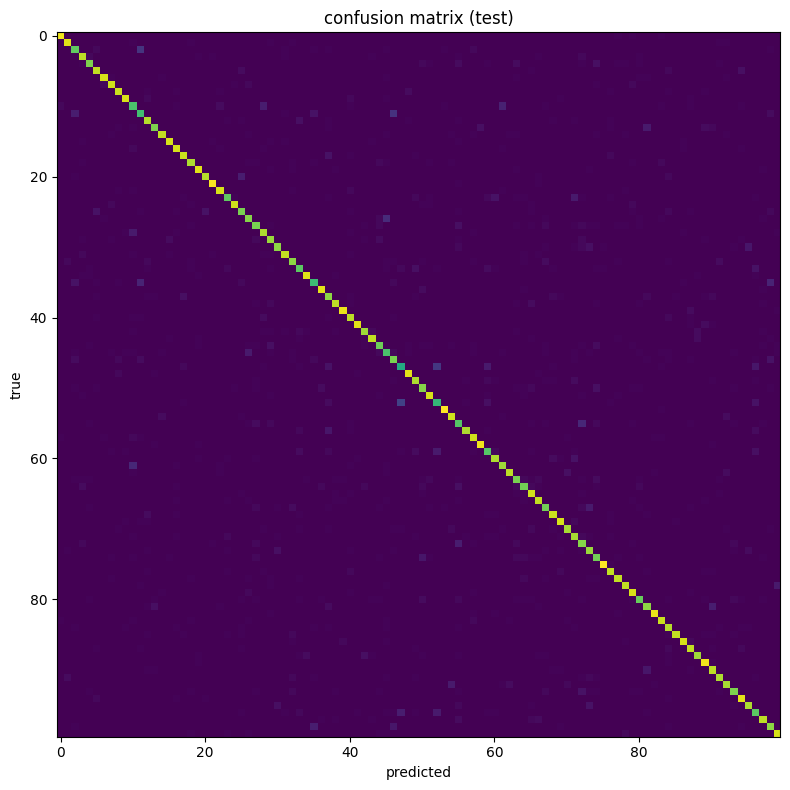

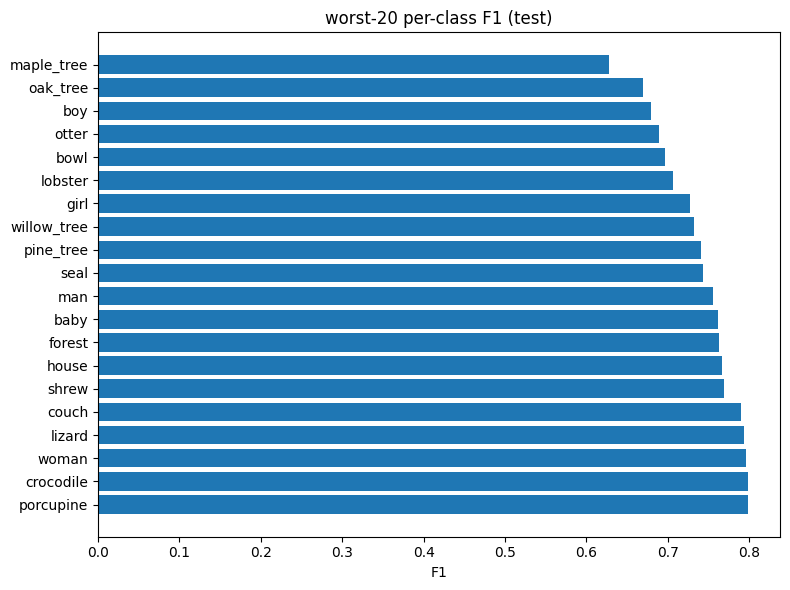

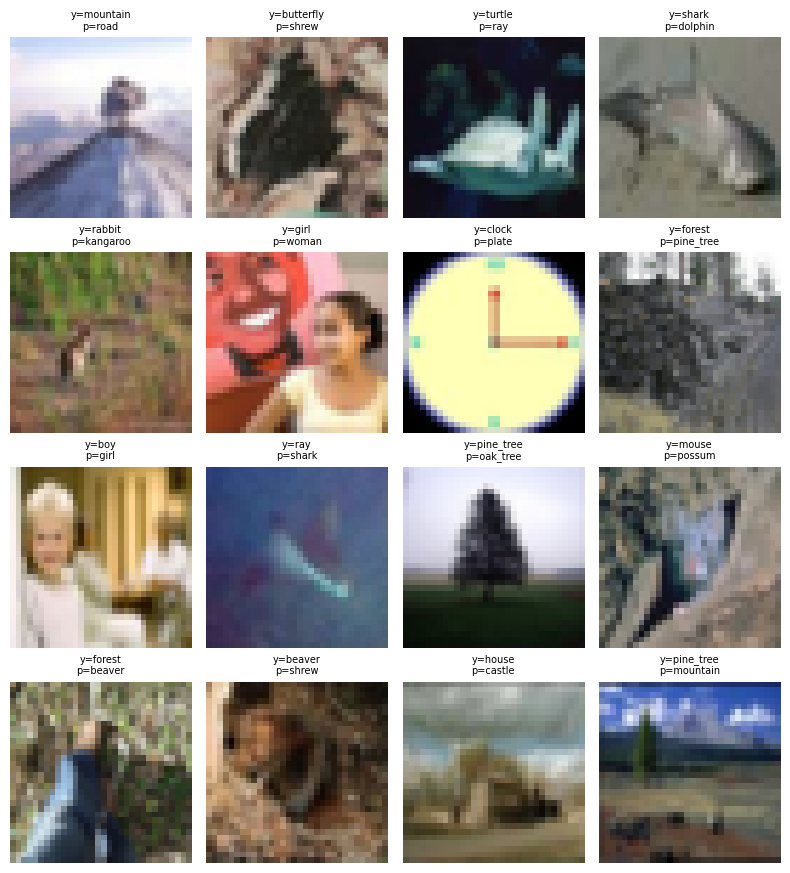

{
  "accuracy": 0.8628,
  "macro_f1": 0.8629142588012725,
  "top3": 0.9538,
  "top5": 0.9719
}


In [17]:
from transformers import AutoModelForImageClassification

def build_model_run_a():
    model = AutoModelForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label={i: n for i, n in enumerate(LABEL_NAMES)},
        label2id={n: i for i, n in enumerate(LABEL_NAMES)},
        ignore_mismatched_sizes=True,
    )
    # Freeze every backbone param; keep classifier head trainable.
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("classifier")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Run A trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%) Kishan)")
    return model

metrics_a = None
model_a = None # Initialize model_a to None
if RUN_TRAINING:
    model_a = build_model_run_a()
    args_a = build_training_args(RUN_A_DIR, epochs=5, lr=3e-4, batch_size=32)
    trainer_a = build_trainer(model_a, args_a)
    trainer_a.train()
    # Save the trained model_a for potential reuse in Run B
    trainer_a.save_model(RUN_A_DIR / "trained_model_a")
    metrics_a = save_run_artifacts(trainer_a, RUN_A_DIR, test_ds, raw_test, LABEL_NAMES)
else:
    print("RUN_TRAINING is False; skipping Run A.")

## 7. Run B — Partial Fine-Tune (Last Block + Head)

Most of the backbone stays frozen; only the **last transformer block**
and the classifier head are trainable. Recommended settings: 3–5 epochs,
batch size 16, learning rate 1e-5 to 3e-5, weight decay 0.01.
Run B starts from Run A's trained model. If Run A was skipped or failed,
it will initialize from the pretrained model.

Loading model from Run A's trained checkpoint.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

unfreezing classifier + last encoder block index 11
Run B trainable params: 7,164,772 / 85,875,556 (8.34%) Kishan)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Top3,Top5
1,0.318983,0.412877,0.879400,0.878712,0.968400,0.983400
2,0.261414,0.399108,0.883000,0.882706,0.970600,0.984000
3,0.225505,0.395282,0.884000,0.883556,0.970600,0.983800
4,0.203470,0.392820,0.884400,0.883978,0.971200,0.984600
5,0.188171,0.391926,0.884200,0.883761,0.971400,0.985000


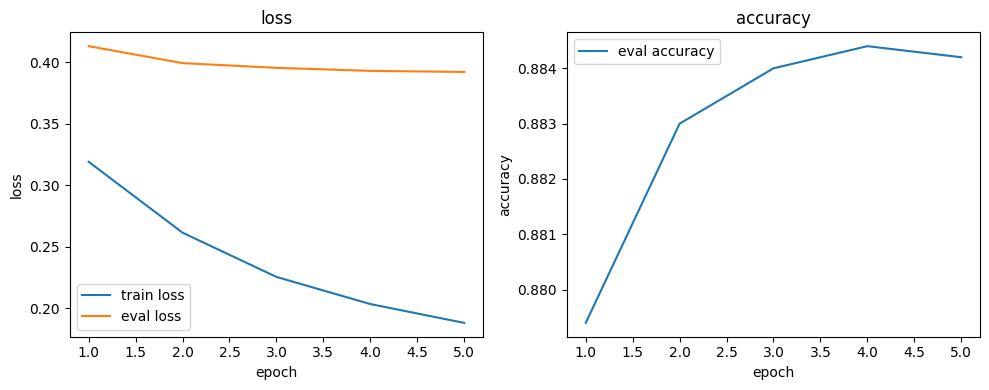

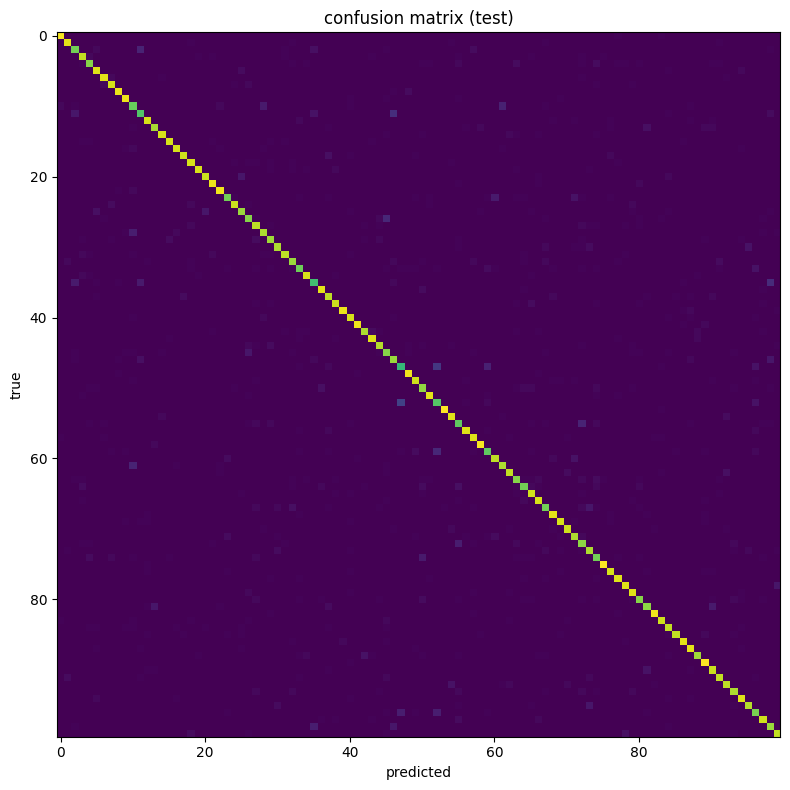

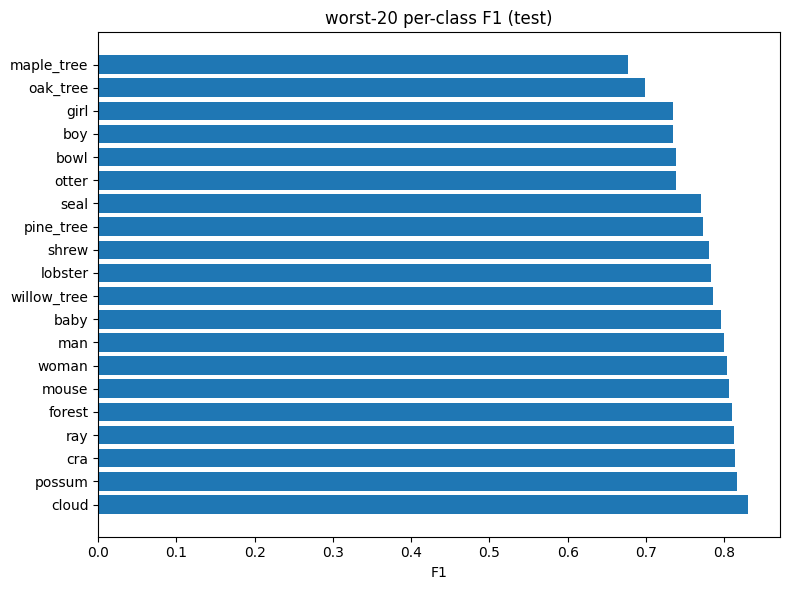

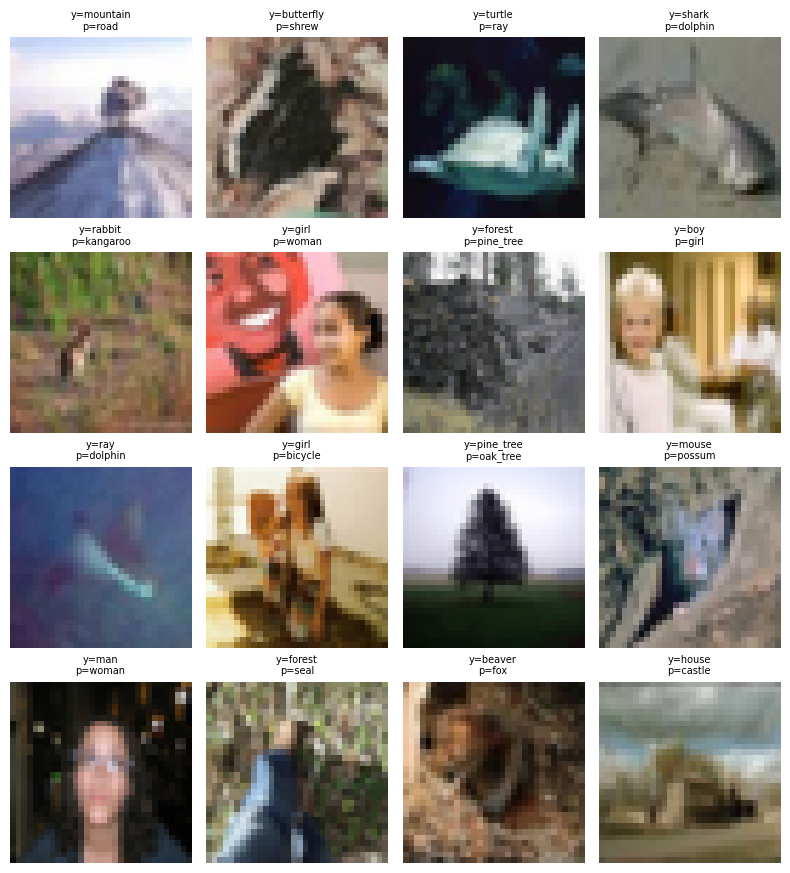

{
  "accuracy": 0.8874,
  "macro_f1": 0.8873360746133683,
  "top3": 0.969,
  "top5": 0.9812
}


In [18]:
def build_model_run_b():
    # Attempt to load model from Run A's output if available and RUN_TRAINING is True
    model_a_path = RUN_A_DIR / "trained_model_a"
    if RUN_TRAINING and model_a_path.exists():
        print("Loading model from Run A's trained checkpoint.")
        model = AutoModelForImageClassification.from_pretrained(
            model_a_path,
            num_labels=NUM_LABELS,
            id2label={i: n for i, n in enumerate(LABEL_NAMES)},
            label2id={n: i for i, n in enumerate(LABEL_NAMES)},
            ignore_mismatched_sizes=True,
        )
    else:
        print("Run A's model not available or RUN_TRAINING is False; initializing from pretrained model.")
        model = AutoModelForImageClassification.from_pretrained(
            MODEL_NAME,
            num_labels=NUM_LABELS,
            id2label={i: n for i, n in enumerate(LABEL_NAMES)},
            label2id={n: i for i, n in enumerate(LABEL_NAMES)},
            ignore_mismatched_sizes=True,
        )

    # Identify the last encoder block by name pattern. ViT/DeiT use
    # 'vit.encoder.layer.<N>' or 'encoder.layer.<N>'; we find the highest N.
    block_indices = set()
    for name, _ in model.named_parameters():
        for token in name.split("."):
            if token.isdigit():
                block_indices.add(int(token))
    if not block_indices:
        raise RuntimeError("Could not locate transformer block indices to unfreeze.")
    last_block = max(block_indices)
    print(f"unfreezing classifier + last encoder block index {last_block}")

    last_block_tag = f".{last_block}."
    for name, p in model.named_parameters():
        p.requires_grad = (
            name.startswith("classifier") or last_block_tag in f".{name}."
        )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Run B trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%) Kishan)")
    return model

metrics_b = None
if RUN_TRAINING:
    model_b = build_model_run_b()
    args_b = build_training_args(RUN_B_DIR, epochs=5, lr=3e-5, batch_size=16)
    trainer_b = build_trainer(model_b, args_b)
    trainer_b.train()
    metrics_b = save_run_artifacts(trainer_b, RUN_B_DIR, test_ds, raw_test, LABEL_NAMES)
else:
    print("RUN_TRAINING is False; skipping Run B.")

## 8. Run C — Optional LoRA (PEFT)

Run only if `RUN_LORA` is True and `peft` installed cleanly. Targets the
attention projection modules of the chosen backbone with LoRA adapters
(rank 8, alpha 16, dropout 0.05), trains adapters + classifier head at
lr=1e-4 for 3–5 epochs. If PEFT cannot wrap the model, we print the
exception, save a `skipped.json`, and continue.

Loading base model for LoRA from Run A's trained checkpoint.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LoRA target modules: ['q_proj', 'k_proj', 'v_proj']


trainable params: 519,268 || all params: 86,394,824 || trainable%: 0.6010


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Top3,Top5
1,0.257533,0.297614,0.909200,0.908946,0.982400,0.991800
2,0.195597,0.279904,0.916800,0.916606,0.983000,0.992800
3,0.157334,0.272566,0.919000,0.918771,0.985000,0.993600
4,0.132125,0.271565,0.920200,0.920014,0.985400,0.993200
5,0.116147,0.270054,0.920200,0.919961,0.985400,0.993600


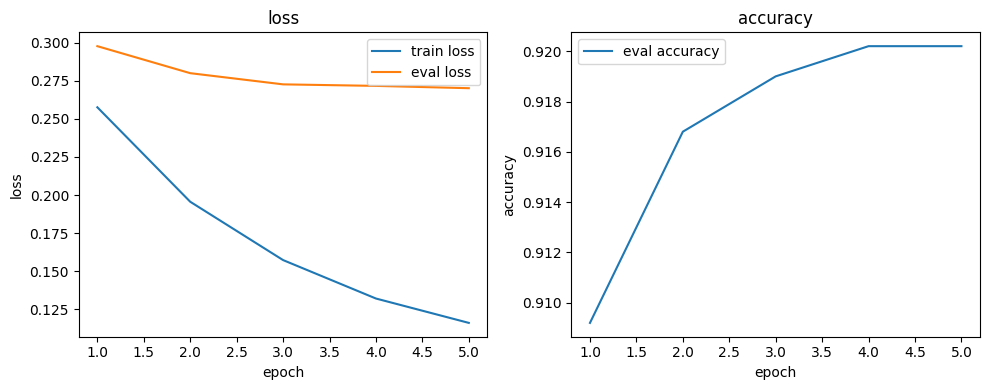

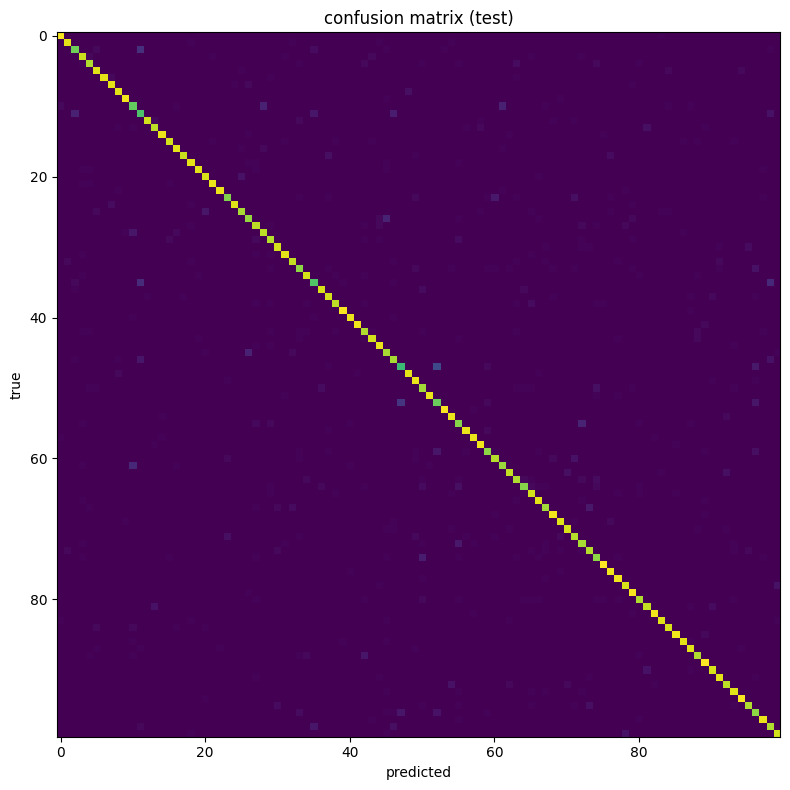

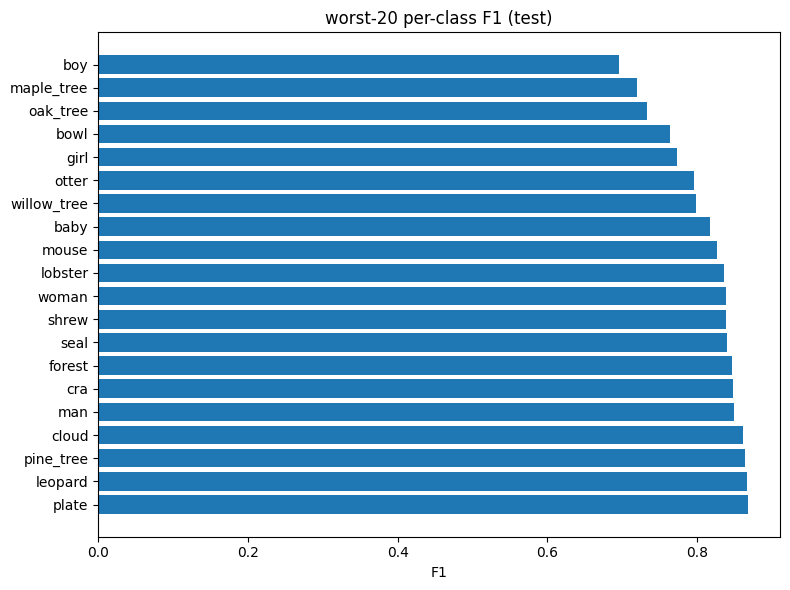

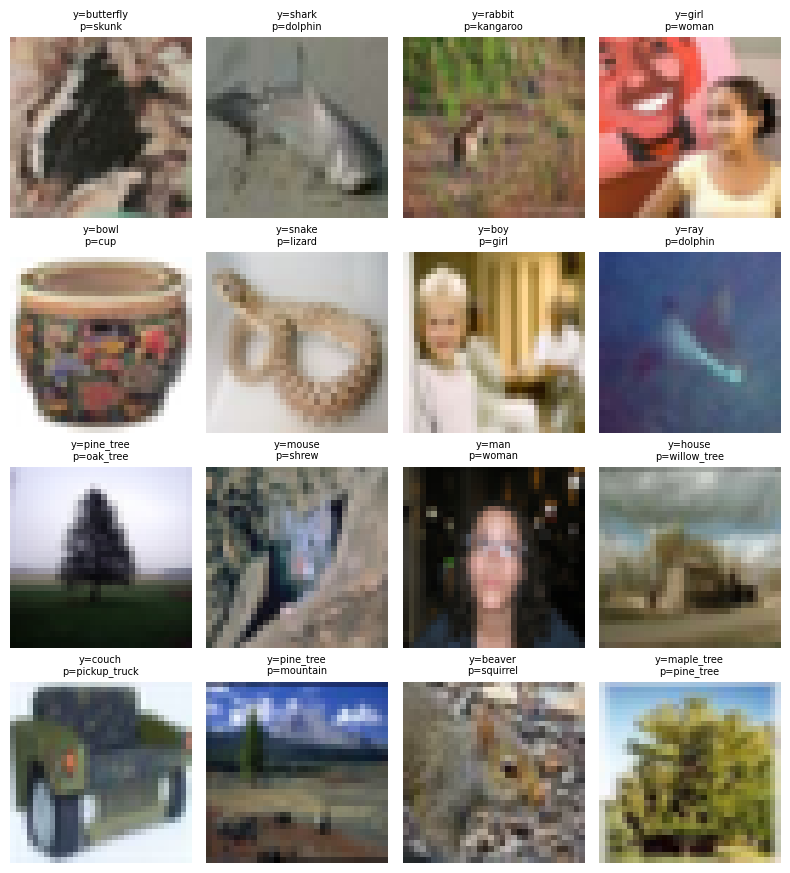

{
  "accuracy": 0.9165,
  "macro_f1": 0.9165044170893293,
  "top3": 0.9831,
  "top5": 0.9919
}


In [19]:
metrics_c = None

def _lora_target_modules_for(model):
    # Heuristic: ViT models typically use 'q_proj', 'k_proj', 'v_proj'
    # for attention projections. We check for these specifically.
    target_names = ["q_proj", "k_proj", "v_proj"]
    # Verify these exist in the model's named parameters
    existing_names = set(n.split(".")[-1] for n, _ in model.named_parameters())
    candidates = [t for t in target_names if t in existing_names]
    return candidates or target_names # Fallback to common names if none found

if RUN_LORA and PEFT_AVAILABLE and RUN_TRAINING:
    try:
        from peft import LoraConfig, get_peft_model, TaskType

        model_a_path = RUN_A_DIR / "trained_model_a"
        if model_a_path.exists():
            print("Loading base model for LoRA from Run A's trained checkpoint.")
            base = AutoModelForImageClassification.from_pretrained(
                model_a_path,
                num_labels=NUM_LABELS,
                id2label={i: n for i, n in enumerate(LABEL_NAMES)},
                label2id={n: i for i, n in enumerate(LABEL_NAMES)},
                ignore_mismatched_sizes=True,
            )
        else:
            print("Run A's trained model not available; initializing LoRA base from pretrained model.")
            base = AutoModelForImageClassification.from_pretrained(
                MODEL_NAME,
                num_labels=NUM_LABELS,
                id2label={i: n for i, n in enumerate(LABEL_NAMES)},
                label2id={n: i for i, n in enumerate(LABEL_NAMES)},
                ignore_mismatched_sizes=True,
            )

        targets = _lora_target_modules_for(base)
        print(f"LoRA target modules: {targets}")

        lora_cfg = LoraConfig(
            r=8,
            lora_alpha=16,
            lora_dropout=0.05,
            bias="none",
            target_modules=targets,
            modules_to_save=["classifier"], # Ensure classifier is trainable
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        model_c = get_peft_model(base, lora_cfg)
        model_c.print_trainable_parameters()

        args_c = build_training_args(RUN_C_DIR, epochs=5, lr=1e-4, batch_size=16)
        trainer_c = build_trainer(model_c, args_c)
        trainer_c.train()
        metrics_c = save_run_artifacts(trainer_c, RUN_C_DIR, test_ds, raw_test, LABEL_NAMES)
    except Exception as exc:
        print(f"LoRA Run C skipped due to: {exc}")
        RUN_C_DIR.mkdir(parents=True, exist_ok=True)
        (RUN_C_DIR / "skipped.json").write_text(
            json.dumps({"skipped": True, "reason": str(exc)}, indent=2)
        )
else:
    print("LoRA Run C not requested (RUN_LORA=False) or PEFT unavailable.")

## 9. Cross-Run Summary

Side-by-side metrics for the runs that completed in this session.
Skipped runs are omitted. The interpretation cell below compares these
transformer results to the EfficientNetB3 / ResNet / DenseNet rows
already documented in `README.md`.

In [20]:
def _safe_load(p):
    try:
        return json.loads(p.read_text())
    except Exception:
        return None

summary = {}
for tag, d in [("run_a_frozen_head", RUN_A_DIR),
               ("run_b_partial_finetune", RUN_B_DIR),
               ("run_c_lora", RUN_C_DIR)]:
    m = _safe_load(d / "metrics.json")
    if m is not None:
        summary[tag] = m

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "summary.json").write_text(json.dumps(summary, indent=2))

if summary:
    # Print a simple markdown-style table.
    cols = ["accuracy", "macro_f1", "top3", "top5"]
    header = "| run | " + " | ".join(cols) + " |"
    sep = "|" + "|".join(["---"] * (len(cols) + 1)) + "|"
    lines = [header, sep]
    for tag, m in summary.items():
        row = "| " + tag + " | " + " | ".join(f"{m[c]:.4f}" for c in cols) + " |"
        lines.append(row)
    print("\n".join(lines))
else:
    print("No runs produced metrics in this session.")

| run | accuracy | macro_f1 | top3 | top5 |
|---|---|---|---|---|
| run_a_frozen_head | 0.8628 | 0.8629 | 0.9538 | 0.9719 |
| run_b_partial_finetune | 0.8874 | 0.8873 | 0.9690 | 0.9812 |
| run_c_lora | 0.9165 | 0.9165 | 0.9831 | 0.9919 |


### Interpretation

- **Run A (frozen head)** isolates the transferred backbone's representation
  quality on CIFAR-100. We expect headroom over the corresponding
  frozen-CNN baselines because ViT-B/16 in21k carries much richer features
  than ImageNet-only CNN backbones of similar parameter count.
- **Run B (partial fine-tune)** matches the partial-unfreeze recipe used
  for `EfficientNetB3 fine unfreeze block 6` and should be compared
  against that row in `README.md`'s run-summary table.
- **Run C (LoRA)** trades raw accuracy for trainable-parameter efficiency.
  When present, compare `macro_f1` and the printed trainable-parameter
  ratio against Run B to judge LoRA's parameter/accuracy trade-off.
- All three runs share the same test split, label set, and metric
  definitions, so the gap to the CNN rows is the transformer's marginal
  contribution under matched evaluation conditions.

### Why training stops after 1 epoch (FAST_DEV_RUN)

Training currently stops after one epoch because `FAST_DEV_RUN` is set to `True` in the `imports-config` cell. This is intended for quick verification of the pipeline.

To perform a full training run, change `FAST_DEV_RUN = False` in the `imports-config` cell and re-run the notebook from that point onwards. Full metrics will only be available when `FAST_DEV_RUN` is `False`.

Expected random baseline accuracy for 100 classes is approximately 1%.

## 10. Download Results

In [21]:
import shutil
from google.colab import files

# Create a zip archive of the output directory
output_zip_path = shutil.make_archive(str(OUTPUT_ROOT), 'zip', OUTPUT_ROOT)

print(f"Results zipped to: {output_zip_path}")

# Download the zip file
files.download(output_zip_path)

Results zipped to: /content/hf_vit_transfer.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>